 # **Univariate Linear Regression Model** ❤

---
<center>

# <font color="hotpink">**DATA PREPARATION**</font>

</center>


---


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
df=pd.read_csv('Salary_dataset.csv')
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [9]:
df = df.drop(columns=['Unnamed: 0'])
df.head()

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [11]:
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.413333,76004.000000
std,2.837888,27414.429785
min,1.200000,37732.000000
25%,3.300000,56721.750000
50%,4.800000,65238.000000
75%,7.800000,100545.750000
max,10.600000,122392.000000


## **Function**
$$f_{w,b}(x^{(i)}) = wx^{(i)} + b$$





In [12]:
x_train = np.array(df['YearsExperience'])
y_train=np.array(df['Salary'])
print(x_train,'\n',y_train)

[ 1.2  1.4  1.6  2.1  2.3  3.   3.1  3.3  3.3  3.8  4.   4.1  4.1  4.2
  4.6  5.   5.2  5.4  6.   6.1  6.9  7.2  8.   8.3  8.8  9.1  9.6  9.7
 10.4 10.6] 
 [ 39344.  46206.  37732.  43526.  39892.  56643.  60151.  54446.  64446.
  57190.  63219.  55795.  56958.  57082.  61112.  67939.  66030.  83089.
  81364.  93941.  91739.  98274. 101303. 113813. 109432. 105583. 116970.
 112636. 122392. 121873.]


In [13]:
print(x_train.shape)
y_train.shape

(30,)


(30,)

In [14]:
print(type(x_train))
type(y_train)

<class 'numpy.ndarray'>


numpy.ndarray

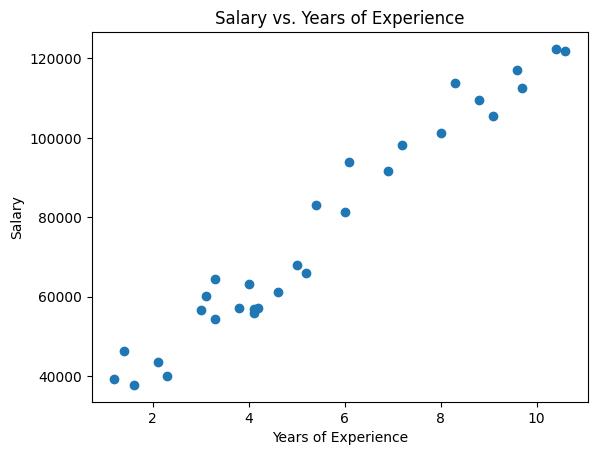

In [15]:
plt.scatter(x_train, y_train)
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Salary vs. Years of Experience")
plt.show()

---
<center>

# <font color="hotpink">**CORE ALGORITHM**</font>

</center>


---



## **Cost Function**
$$J(w,b) = \frac{1}{2m} \sum_{i=0}^{m-1} \left( f_{w,b}(x^{(i)}) - y^{(i)} \right)^2$$









In [16]:
def cost_ftn(x, y, w, b):
  m = x.shape[0]
  cost = 0.0
  for i in range(m):
    f_wb_i = w * x[i] + b
    cost = cost + (f_wb_i - y[i])**2
  total_cost = cost / (2 * m)
  return total_cost

## **Partial Derivatives**
$$\frac{\partial}{\partial w} J(w,b) = \frac{1}{m} \sum_{i=0}^{m-1} \left( f_{w,b}(x^{(i)}) - y^{(i)} \right) x^{(i)}$$

$$\frac{\partial}{\partial b} J(w,b) = \frac{1}{m} \sum_{i=0}^{m-1} \left( f_{w,b}(x^{(i)}) - y^{(i)} \right)$$






In [17]:
def der_w(x,y,w,b):
 m=x.shape[0]
 sum_dj_dw=0
 for i in range(m):
  f_wb=w*x[i]+b
  sum_dj_dw=sum_dj_dw+((f_wb-y[i])*x[i])
 return sum_dj_dw/m

def der_b(x,y,w,b):
 m=x.shape[0]
 sum_dj_db=0
 for i in range(m):
  f_wb=w*x[i]+b
  sum_dj_db=sum_dj_db+(f_wb-y[i])
 return sum_dj_db/m

## **Gradient Descent**
**Repeat until convergence:**
$$\left\{
\begin{aligned}
w &= w - \alpha \frac{\partial}{\partial w} J(w,b) \\
b &= b - \alpha \frac{\partial}{\partial b} J(w,b)
\end{aligned}
\right\}$$







In [18]:
def gradient_descent(x, y, w_in, b_in, alpha, num_iters, cost_function, der_w_function, der_b_function):
  w = w_in
  b = b_in
  for i in range(num_iters):
    dj_dw = der_w_function(x, y, w, b)
    dj_db = der_b_function(x, y, w, b)
    w = w - alpha * dj_dw
    b = b - alpha * dj_db
  return w, b

In [19]:
w_init = 0
b_init = 0
alpha = 0.01
num_iters = 10000
w, b = gradient_descent(x_train, y_train, w_init, b_init, alpha, num_iters, cost_ftn, der_w, der_b)
print(f"Optimal w: {w:.2f}, Optimal b: {b:.2f}")

Optimal w: 9449.96, Optimal b: 24848.20


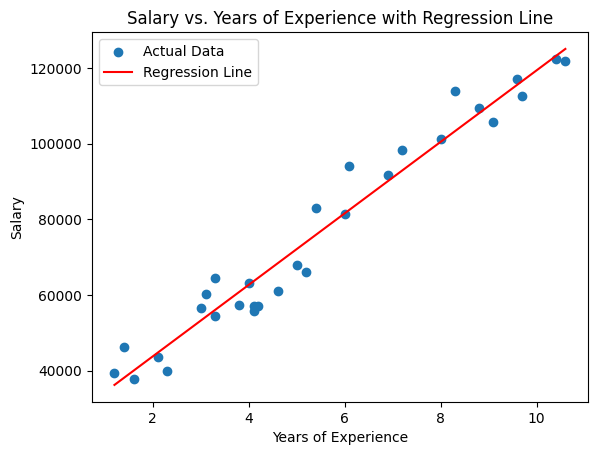

In [20]:
plt.scatter(x_train, y_train, label='Actual Data')
y_pred = w * x_train + b
plt.plot(x_train, y_pred, color='red', label='Regression Line')
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Salary vs. Years of Experience with Regression Line")
plt.legend()
plt.show()

---
<center>

# <font color="hotpink">**TESTING THE MODEL**</font>

</center>


---


In [21]:
new_experience = 5
predicted_salary = w * new_experience + b
print(f"Predicted salary for {new_experience} years of experience: {predicted_salary:.2f}")

Predicted salary for 5 years of experience: 72098.02
